# EmporiUm Sales Analysis - Maryland and New Jersey

This notebook analyzes in-store sales data for two assigned EmporiUm territories.
The full analysis covers store performance, monthly revenue, top customers, product categories,
and a marketing recommendation for next quarter.

**Territories:** Maryland (9 stores, managed by Shruti Reddy) | New Jersey (16 stores, managed by Miami Vue)

**Data Period:** January 2022 - December 2025 

**Total Transactions:** 127,661

In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing the three tools used throughout this analysis

import numpy as np # math operations - averages, standard deviation
import pandas as pd # data loading, cleaning, filtering, grouping, merging
import matplotlib.pyplot as plt  # building charts and visualizations

In [3]:
# The main sales file - contains every transaction recorded across all stores
# .info() shows column names, data types, and non-null counts - confirms data loaded correctly
# .head() previews first 5 rows to verify structure before analysis

st_sales = pd.read_csv("StoreSales.csv")
st_sales.info()
st_sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [4]:
# Store details file contains store location, state, territory manager, and region for every store
# This is how we know which Store ID belongs to which territory

st_details= pd.read_csv("StoreDetail.csv")
st_details.info()
st_details.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [5]:
# Product categories file - translates CategoryID numbers into readable names
product_cg = pd.read_csv("ProductCategories.csv")
product_cg.info()
product_cg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [6]:
# Products file - connects each product number to its category

Products_if = pd.read_csv("Products.csv")
Products_if.info()
Products_if.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [7]:
# Customer rewards list - used to identify top customers by name
# sep='|' because this file uses pipe as separator instead of the standard comma
# .str.title() cleans column names to consistent Title Case


Costumers_if = pd.read_csv("customer_list.csv", sep="|")

Costumers_if.columns = Costumers_if.columns.str.title()

Costumers_if.info()
Costumers_if.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Cust_Id       521 non-null    int64 
 1   Date          521 non-null    object
 2   Time          521 non-null    object
 3   Name          521 non-null    object
 4   Email         521 non-null    object
 5   Phone         520 non-null    object
 6   Sms-Opt-Out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,Cust_Id,Date,Time,Name,Email,Phone,Sms-Opt-Out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Core Marketing Analysis

The following sections answer the six core questions requested by the marketing manager.
Each section includes the question, the code to answer it, and a written summary of findings.

## Question 1 - Territory Overview
**Who are the territory managers and what stores are in each assigned territory?**

Before any analysis we need to understand the territory structure - who manages each territory
and which store locations and IDs are included.

In [8]:
# Filter StoreDetail to only include our two assigned territories
# .isin() checks if State is in the list - returns both Maryland and New Jersey in one step
# Displaying only the columns that answer the question - no unnecessary data

NM_stores = st_details[st_details['State'].isin(['New Jersey', 'Maryland'])]

NM_stores[['State', 'Territory Manager', 'Store ID', 'Store Location']].sort_values('State')

,State,Territory Manager,Store ID,Store Location
43,Maryland,Shruti Reddy,731,Annapolis
44,Maryland,Shruti Reddy,732,Back River
45,Maryland,Shruti Reddy,733,Baltimore
46,Maryland,Shruti Reddy,734,Germantown
47,Maryland,Shruti Reddy,735,Howard
48,Maryland,Shruti Reddy,736,North Harford
49,Maryland,Shruti Reddy,737,Parkville
50,Maryland,Shruti Reddy,738,Queen Anne's County
51,Maryland,Shruti Reddy,739,Ridgely
83,New Jersey,Miami Vue,837,Paterson


### Finding - Question 1

- **Maryland** is managed by **Shruti Reddy** and has **9 stores** located in cities including North Harford, Germantown, Parkville, Baltimore, and Annapolis
- **New Jersey** is managed by **Miami Vue** and has **16 stores** located in cities including Newark, Trenton, Hoboken, Atlantic City, and Paterson
- Both territories are part of the Northeast region

## Question 2 - Monthly Total Revenue by Territory
**What is the monthly total revenue for in-store sales in each territory over the full data period?**

This section filters sales to our territories, prepares the date columns,
and calculates monthly revenue totals for each territory from January 2022 through December 2025.

In [9]:
# Filter StoreSales to only transactions from our 25 territory stores
# .isin() matches Store ID against our territory store list
# .copy() creates an independent DataFrame to avoid pandas warnings

northeast_sales = st_sales[st_sales['Store ID'].isin(NM_stores['Store ID'])].copy()


# Merge in State and Store Location from StoreDetail using Store ID as the bridge
# Without this merge our sales data has no location or territory information

northeast_sales = northeast_sales.merge(
    NM_stores[['Store ID', 'Store Location', 'State']], on='Store ID')

In [10]:
# Convert Transaction Date from plain text to a real datetime pandas understands
# Without this conversion pandas cannot group by month or year

northeast_sales['Transaction Date'] = pd.to_datetime(northeast_sales['Transaction Date'])


# Create YearMonth column like '2022-01' for grouping and chart x-axis labels
# .dt.to_period('M') extracts the year-month from each date
# .astype(str) converts it to text so matplotlib can use it as a label

northeast_sales['YearMonth'] = northeast_sales['Transaction Date'].dt.to_period('M').astype(str)

In [11]:
# Split the combined territory data into two separate DataFrames
# Used when analyzing each territory independently
# .copy() ensures changes to one do not affect the other

maryland_sales = northeast_sales[northeast_sales['State'] == 'Maryland'].copy()
nj_sales = northeast_sales[northeast_sales['State'] == 'New Jersey'].copy()

In [12]:
# Territory summary - total transactions and total revenue over the years side by side
# Dictionary builds the data structure, pd.DataFrame() converts it to a display table

# Dictionary to bild the table before putting it on pandas
summary = {
    'Territory'         : ['Maryland', 'New Jersey'],
    'Total Transactions': [len(maryland_sales), len(nj_sales)],
    'Total Revenue'     : [maryland_sales['Sale Amount'].sum(),  nj_sales['Sale Amount'].sum()]
}

# Making the DataFrame
summary_df = pd.DataFrame(summary)

summary_df

,Territory,Total Transactions,Total Revenue
0,Maryland,89466,11451615.09
1,New Jersey,38195,5175405.87


In [13]:
# Monthly revenue - one total per territory per month across the full 4 year period
# .groupby() groups rows by State and YearMonth - creates one bucket per combination
# .agg(Total_Revenue='sum') adds up Sale Amount inside each bucket
# .sort_values() arranges results in chronological order for clean reading and charting

monthly_revenue = northeast_sales.groupby(['State', 'YearMonth'],
as_index=False )['Sale Amount'].agg ( Total_Revenue ='sum').sort_values(['State', 'YearMonth'])


monthly_revenue

,State,YearMonth,Total_Revenue
0,Maryland,2022-01,190064.90
1,Maryland,2022-02,197529.18
2,Maryland,2022-03,210228.48
3,Maryland,2022-04,179004.18
4,Maryland,2022-05,212028.70
...,...,...,...
91,New Jersey,2025-08,151923.99
92,New Jersey,2025-09,163449.78
93,New Jersey,2025-10,250830.46
94,New Jersey,2025-11,146953.33


### Finding - Question 2

- **Maryland total revenue:** $11,451,615 from 89,466 transactions
  
- **New Jersey total revenue:** $5,175,405 from 38,195 transactions


 Both territories show **consistent growth from 2022 to 2025**
Revenue dips slightly in early months (January–February) and peaks toward end of year - consistent with back-to-school and holiday shopping patterns
Maryland consistently outperforms New Jersey every single month across the full 4-year period

### Chart 1 - Monthly Revenue Trend
A line chart is the right choice here because we are looking at a **trend over time**.
Each territory gets its own line so the marketing team can compare them at a glance.

In [14]:
# Separate territories for individual lines on the chart
md = monthly_revenue[monthly_revenue['State'] == 'Maryland']
nj = monthly_revenue[monthly_revenue['State'] == 'New Jersey']

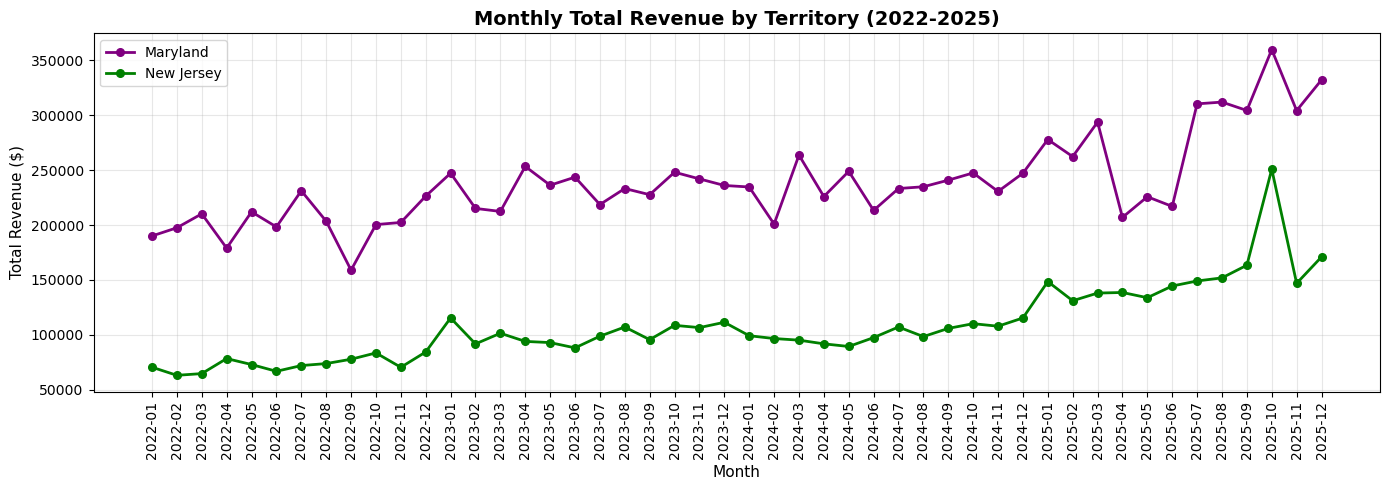

In [15]:
# Line chart - best choice for showing trends over time
# figsize=(14,5) - wide canvas fits all 48 month labels comfortably
fig, ax = plt.subplots(figsize=(14, 5))

# marker='o' adds a dot at each data point - easier to read individual months
ax.plot(md['YearMonth'], md['Total_Revenue'],
        label='Maryland', color='purple', marker='o', markersize=5.5, linewidth=2)
ax.plot(nj['YearMonth'], nj['Total_Revenue'],
        label='New Jersey', color='green', marker='o', markersize=5.5, linewidth=2)

ax.set_title('Monthly Total Revenue by Territory (2022-2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)

# Grid lines help trace values across 48 months - alpha=0.3 keeps them subtle
plt.grid(True, alpha=0.3)
ax.legend()

# Rotate labels 90 degrees so 48 month labels do not overlap each other
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## Question 3 - Store Performance Ranking
**How would you rank the sales performance of each store? Which are the top-performing stores?**

Ranking stores by total revenue shows us which locations are driving the most business
and which may need more marketing support.

In [16]:
# Group all Maryland transactions by store groups
Mary_Sale_Report = maryland_sales.groupby(
    ['Store Location','Store ID'], as_index=False

# .agg(Total_Revenue='sum') calculates total revenue for each store across all years

    )['Sale Amount'].agg(Total_Revenue='sum'
                             
# Making the raking filter for the data, and ranking from highh to lower 
# .sort_values(ascending=False) puts the highest earner first
# .reset_index(drop=True) gives clean row numbers starting from 0 - needed for plotting
                         
    ).sort_values('Total_Revenue', ascending=False).reset_index(drop=True) 


Mary_Sale_Report

,Store Location,Store ID,Total_Revenue
0,North Harford,736,8708119.00
1,Germantown,734,584675.92
2,Parkville,737,320441.24
3,Howard,735,319394.58
4,Ridgely,739,318511.04
5,Baltimore,733,310099.90
6,Back River,732,303433.61
7,Queen Anne's County,738,298074.49
8,Annapolis,731,288865.31


In [17]:
# Same ranking for New Jersey stores - same structure for easy comparison


# Group all Maryland transactions by store groups
Nj_Sale_Report = nj_sales.groupby(
    ['Store Location', 'Store ID'], as_index=False
    
# adding all sales together  to then get a individual total revenue by store 
    
    )['Sale Amount'].agg(Total_Revenue='sum'
                         
# Making the raking filter for the data, and ranking from highh to lower 
                         
    ).sort_values('Total_Revenue', ascending=False).reset_index(drop=True)

Nj_Sale_Report

,Store Location,Store ID,Total_Revenue
0,Newark,835,623163.53
1,Trenton,838,597565.68
2,Hoboken,830,316775.48
3,Atlantic City,824,314513.77
4,New Brunswick,834,311056.42
5,Morristown,833,307320.52
6,Vineland,839,306326.30
7,Clifton,827,301703.77
8,Passaic,836,300358.95
9,East Orange,828,299936.24


In [18]:
# Quick print summary of top 3 stores in each territory
# .head(3) returns only the top 3 ranked rows

print("MARYLAND TOP 3 STORES:")
print(Mary_Sale_Report.head(3))
print()
print("NEW JERSEY TOP 3 STORES:")
print(Nj_Sale_Report.head(3))

MARYLAND TOP 3 STORES:
  Store Location  Store ID  Total_Revenue
0  North Harford       736     8708119.00
1     Germantown       734      584675.92
2      Parkville       737      320441.24

NEW JERSEY TOP 3 STORES:
  Store Location  Store ID  Total_Revenue
0         Newark       835      623163.53
1        Trenton       838      597565.68
2        Hoboken       830      316775.48


### Finding - Question 3

**Maryland:**
- #1 North Harford - $8,708,119 (generates 76% of Maryland's total revenue alone)
  
- #2 Germantown - $584,676

- #3 Parkville - $320,441

New Jersey:
- #1 Newark - $623,164
  
- #2 Trenton - $597,566

- #3 Hoboken - $316,775

Key insight: North Harford is an extreme outlier in Maryland - it outperforms the next store by 15x.
New Jersey stores are far more balanced with no single dominant location.
Understanding what drives North Harford's performance could unlock growth at other Maryland stores.

### Chart 2 - Top Performing Stores
A bar chart is the right choice here because we are **comparing stores against each other** - not looking at a trend over time.

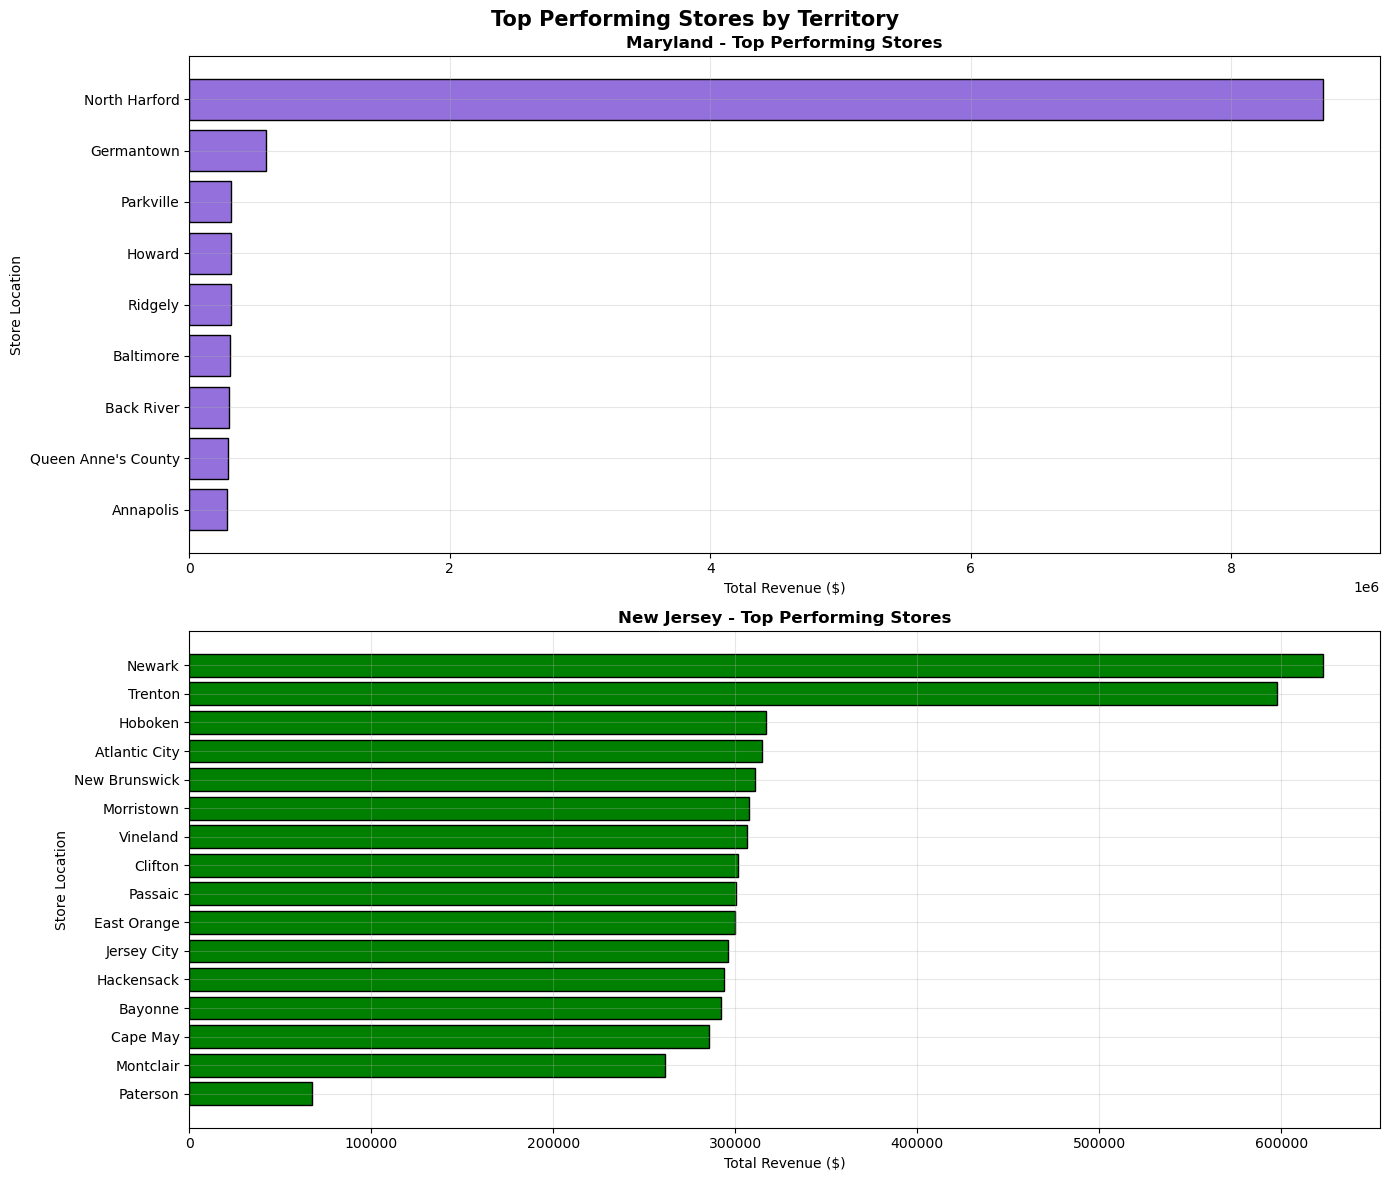

In [23]:
# Horizontal bar chart - store names are easier to read on the y axis
# Two stacked charts so each territory gets its own scale
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Maryland - sorted ascending so highest bar appears at the top
md_sorted = Mary_Sale_Report.sort_values('Total_Revenue')
ax1.barh(md_sorted['Store Location'], md_sorted['Total_Revenue'],
         color='mediumpurple', edgecolor='black')
ax1.set_title('Maryland - Top Performing Stores', fontweight='bold')
ax1.set_xlabel('Total Revenue ($)')
ax1.set_ylabel('Store Location')
ax1.grid(True, alpha=0.3)

# New Jersey - same structure for consistent side by side reading
nj_sorted = Nj_Sale_Report.sort_values('Total_Revenue')
ax2.barh(nj_sorted['Store Location'], nj_sorted['Total_Revenue'],
         color='green', edgecolor='black')
ax2.set_title('New Jersey - Top Performing Stores', fontweight='bold')
ax2.set_xlabel('Total Revenue ($)')
ax2.set_ylabel('Store Location')
ax2.grid(True, alpha=0.3)

plt.suptitle('Top Performing Stores by Territory', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Question 4 - Top Customers
**Comparing the customer ID from the customer list with the rewards ID from sales data - who were the top customers in each territory?**

This section matches rewards members from the sales data to real customer names
using the customer list file, then ranks them by total spending.

In [26]:
# Step 1 - Remove transactions with no RewardsID
# Non-rewards customers cannot be matched to a name so we exclude them here
# .dropna(subset=['RewardsID']) only removes rows where RewardsID is empty
# .copy() prevents SettingWithCopyWarning when we modify the DataFrame next

reward_sales = northeast_sales.dropna(subset=['RewardsID']).copy()


# Step 2 - Convert RewardsID from float (357.0) to integer (357)
# The customer list uses integers - both must match the same type for the merge to work

reward_sales['RewardsID'] = reward_sales['RewardsID'].astype(int)


# Step 3 - Bring customer names in from the customer list
# .rename() makes cust_id match RewardsID so we can use simple on= instead of left_on/right_on
# how='left' keeps all sales rows even if the customer is not found in the list

reward_sales = reward_sales.merge(
    Costumers_if[['Cust_Id', 'Name']].rename(columns={'Cust_Id': 'RewardsID'}),
    on='RewardsID', how='left')


In [28]:
# Add up total spending per customer per territory
# Total_Spent='sum' - lifetime spend across all transactions
# Total_Transactions='count' - how many times they visited
# Highest spender appears first

top_customers = reward_sales.groupby(
    ['State', 'Name'], as_index=False
)['Sale Amount'].agg(
    Total_Spent='sum',
    Total_Transactions='count'
).sort_values('Total_Spent', ascending=False)

In [30]:
# Show top 5 customers per territory
# display() renders a clean formatted table in Jupyter that is |better than print()

md_top = top_customers[top_customers['State'] == 'Maryland'].head()
nj_top = top_customers[top_customers['State'] == 'New Jersey'].head()

print('Top 5- Costumer Maryland')
display(md_top)
print()
print('Top 5 Costumers - New jersey')
display(nj_top)

Top 5- Costumer Maryland


,State,Name,Total_Spent,Total_Transactions
99,Maryland,Cole Brown,7602.28,26
133,Maryland,Donna Hayward,7081.17,24
35,Maryland,Avon Barksdale,6172.68,27
484,Maryland,Trent Lane,6076.89,22
315,Maryland,Magnitude,5916.81,20



Top 5 Costumers - New jersey


,State,Name,Total_Spent,Total_Transactions
704,New Jersey,Gus Fring,5005.07,12
557,New Jersey,Ben Linus,4810.66,8
786,New Jersey,Kim Wexler,4215.58,7
880,New Jersey,Nicky Nichols,4164.21,12
753,New Jersey,Jesse Pinkman,4097.15,14


### Finding - Question 4

The rewards program data shows active repeat customers in both territories.
Top customers have multiple transactions across the data period - a strong sign of brand loyalty.
These high-value customers represent an opportunity for targeted retention campaigns
such as exclusive early access to new tech products or loyalty discounts.

## Question 5 - Product Category Analysis
What is the number of transactions per month by product category in each territory?
What is total sales revenue per month by category?
What might this tell us about the most popular products and where there is opportunity for growth?**


In [33]:
# northeast_sales  has Prod Num + Sale Amount + State + Year + Month - connect on Prod Num
# Products_if has Prod Num + CategoryID - connect on CategoryID
# product_cg  has CategoryID + Category name

# 3 tables will need to be merge to obtain the transactions per month by category

# 1 merge - connect sales with products
Transactions_per_M = northeast_sales.merge(
    Products_if[['Prod Num', 'CategoryID']], on = 'Prod Num')

# 2 merge - get in category names
# .drop_duplicates() keeps only one row per category - prevents data multiplication

Transactions_per_M = Transactions_per_M.merge(
    product_cg[['CategoryID', 'Category']].drop_duplicates(),
    on = 'CategoryID')


### Transactions and Revenue Per Month by Category

In [36]:
# This answers both parts of the question: how many transactions andhow much revenue
# .groupby() creates one group per State + YearMonth + Category combination
# count = number of transactions, sum = total revenue

category_analysis = Transactions_per_M.groupby(
    ['State', 'YearMonth', 'Category'], as_index=False
)['Sale Amount'].agg(
    Total_Transactions='count',
    Total_Revenue='sum'
).sort_values(['State', 'YearMonth'])
category_analysis

,State,YearMonth,Category,Total_Transactions,Total_Revenue
0,Maryland,2022-01,Apparel and Merchandise,260,8321.14
1,Maryland,2022-01,Art Supplies,263,8125.76
2,Maryland,2022-01,Books (General),295,10705.31
3,Maryland,2022-01,Stationery and Supplies,247,2565.06
4,Maryland,2022-01,Technology & Accessories,287,116744.81
...,...,...,...,...,...
571,New Jersey,2025-12,Art Supplies,189,6384.20
572,New Jersey,2025-12,Books (General),78,1932.69
573,New Jersey,2025-12,Stationery and Supplies,227,2307.96
574,New Jersey,2025-12,Technology & Accessories,281,131024.14


In [37]:
# Overall category totals - all months combined

# This gives us a clear overall picture of which categories perform best
# Used as the data source for the category charts below
popular_categories = Transactions_per_M.groupby(
    ['State', 'Category'], as_index=False
)['Sale Amount'].agg(
    Total_Transactions='count',
    Total_Revenue='sum'
).sort_values('Total_Revenue', ascending=False)

# Separate by territory for individual charts
md_categories = popular_categories[popular_categories['State'] == 'Maryland']
nj_categories = popular_categories[popular_categories['State'] == 'New Jersey']

popular_categories

,State,Category,Total_Transactions,Total_Revenue
4,Maryland,Technology & Accessories,16836,7826937.84
10,New Jersey,Technology & Accessories,7883,3630738.42
5,Maryland,Textbooks,11639,2021177.87
11,New Jersey,Textbooks,5419,936799.67
0,Maryland,Apparel and Merchandise,15547,500587.47
2,Maryland,Books (General),15335,494845.76
1,Maryland,Art Supplies,13454,433996.67
6,New Jersey,Apparel and Merchandise,7353,237281.41
7,New Jersey,Art Supplies,6129,197096.50
3,Maryland,Stationery and Supplies,16655,174069.48


### Finding - Question 5

**Technology and Accessories** is both the highest revenue AND highest transaction category - customers buy it often AND spend more when they do. This is the strongest performing category.
  
**Stationery and Supplies** has the most transactions but the lowest revenue - customers come in frequently but each purchase is small. Classic upsell opportunity.
  
 **Textbooks** generates strong revenue with fewer transactions - high-value infrequent purchases likely tied to semester schedules.

## Question 6 — Marketing Recommendation for Next Quarter

**1. Technology and Accessories — Keep it the priority**
Top revenue category in both territories. Any marketing here has the highest return.

**2. Stationery — Upsell opportunity**
Most transactions but lowest revenue. These customers visit often but spend little.
A bundle promotion could easily increase what they spend per visit.

**3. North Harford — Study it and replicate it**
One store generating 76% of Maryland's revenue is unusual.
Understanding why and applying it to other stores could transform the territory.

**4. New Jersey — Focus on the bottom stores**
Paterson and Montclair are significantly below average.
Targeted local campaigns at these locations would lift the whole territory.